In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Load the data
sales_df = pd.read_excel('Onyx Data - DataDNA Dataset Challenge - Mobile Phone Sales Dataset - May 2025.xlsx', sheet_name='Fact_Sales')
products_df = pd.read_excel('Onyx Data - DataDNA Dataset Challenge - Mobile Phone Sales Dataset - May 2025.xlsx', sheet_name='Dim_Products')
locations_df = pd.read_excel('Onyx Data - DataDNA Dataset Challenge - Mobile Phone Sales Dataset - May 2025.xlsx', sheet_name='Dim_Locations')

# Convert date columns to datetime
sales_df['Transaction_Date'] = pd.to_datetime(sales_df['Transaction_Date'])
sales_df['End of Month'] = pd.to_datetime(sales_df['End of Month'])

# Merge dataframes for comprehensive analysis
merged_df = sales_df.merge(products_df, on=['Mobile_Model', 'Brand', 'Operating_System', 'Storage_Size', 'Color'], how='left')
merged_df = merged_df.merge(locations_df, on=['City', 'Country', 'Latitude', 'Longitude'], how='left')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

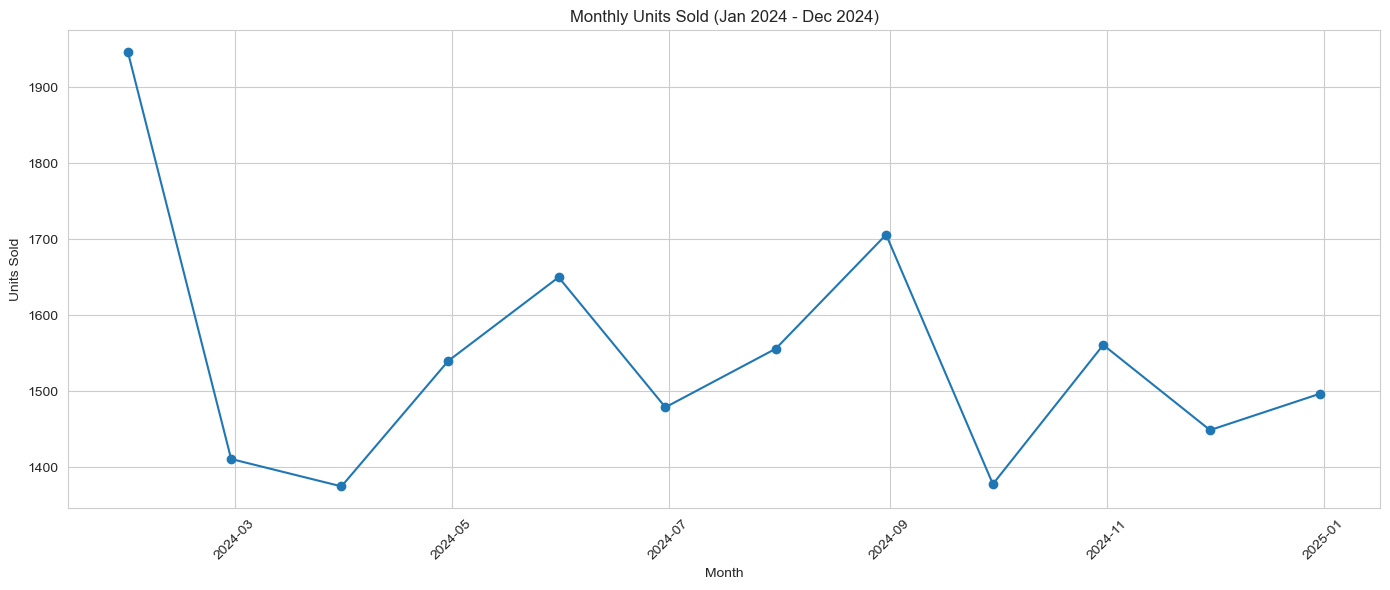

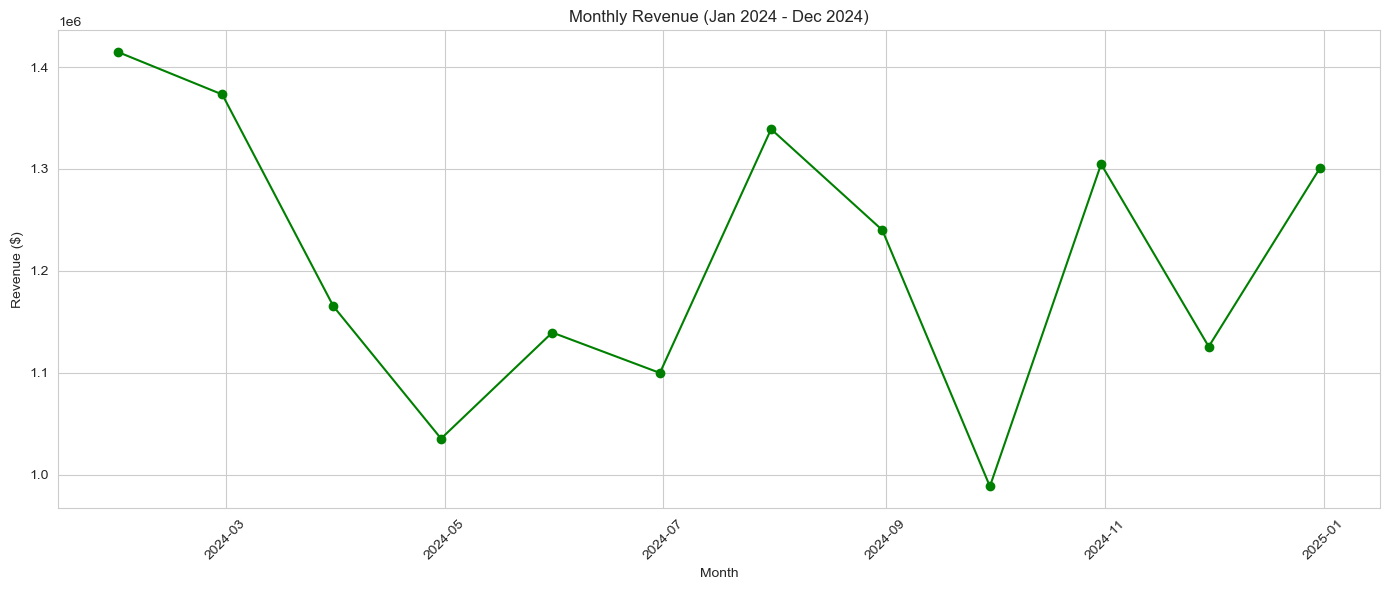

In [4]:
# Monthly sales trends
monthly_sales = sales_df.groupby(pd.Grouper(key='End of Month', freq='M')).agg({
    'Units_Sold': 'sum',
    'Total_Revenue': 'sum'
}).reset_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['End of Month'], monthly_sales['Units_Sold'], marker='o', label='Units Sold')
plt.title('Monthly Units Sold (Jan 2024 - Dec 2024)')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['End of Month'], monthly_sales['Total_Revenue'], marker='o', color='green', label='Revenue')
plt.title('Monthly Revenue (Jan 2024 - Dec 2024)')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

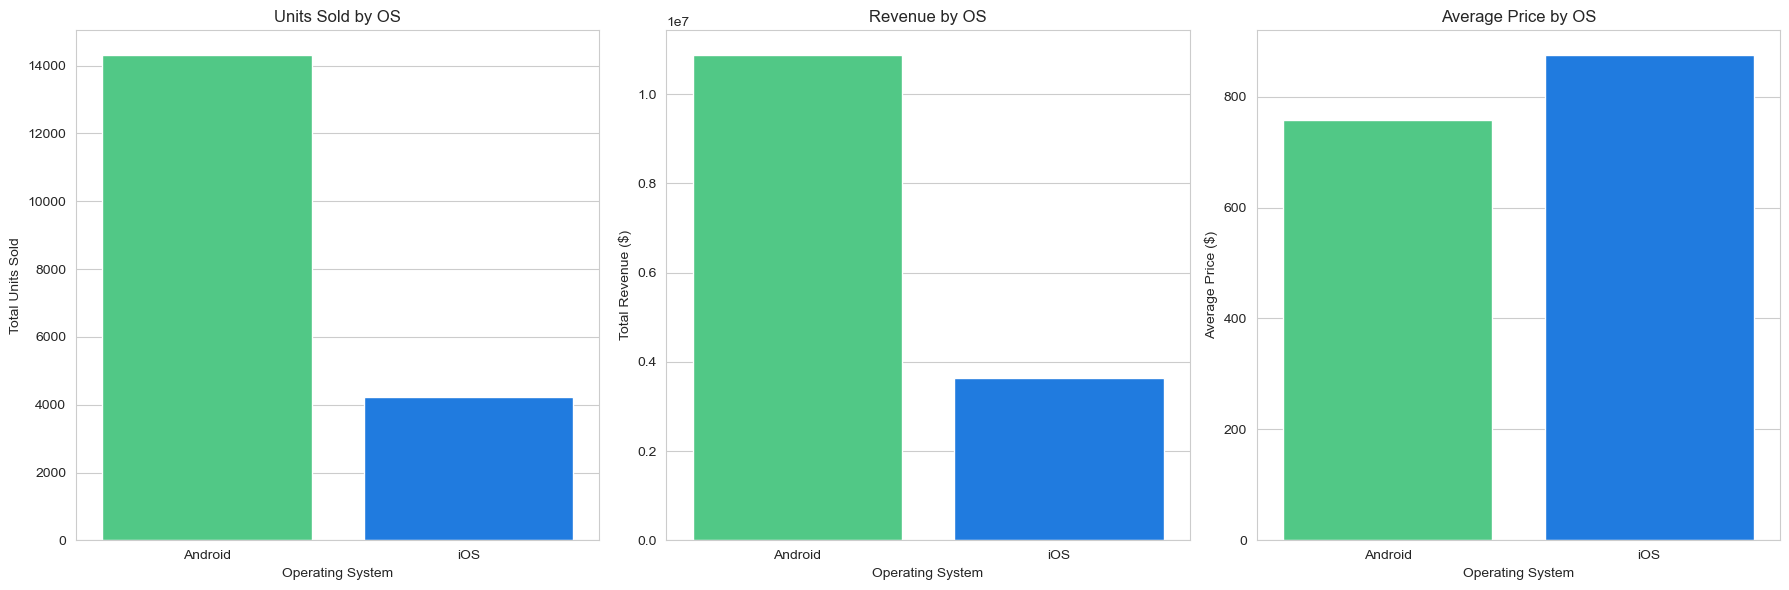

In [8]:

# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Units sold by OS
sns.barplot(x=os_sales.index, y=os_sales['Units_Sold'], ax=ax1, palette=['#3DDC84', '#007AFF'])
ax1.set_title('Units Sold by OS')
ax1.set_xlabel('Operating System')
ax1.set_ylabel('Total Units Sold')

# Revenue by OS
sns.barplot(x=os_sales.index, y=os_sales['Total_Revenue'], ax=ax2, palette=['#3DDC84', '#007AFF'])
ax2.set_title('Revenue by OS')
ax2.set_xlabel('Operating System')
ax2.set_ylabel('Total Revenue ($)')

# Average price by OS
sns.barplot(x=os_sales.index, y=os_sales['Price'], ax=ax3, palette=['#3DDC84', '#007AFF'])
ax3.set_title('Average Price by OS')
ax3.set_xlabel('Operating System')
ax3.set_ylabel('Average Price ($)')

plt.tight_layout()
plt.show()



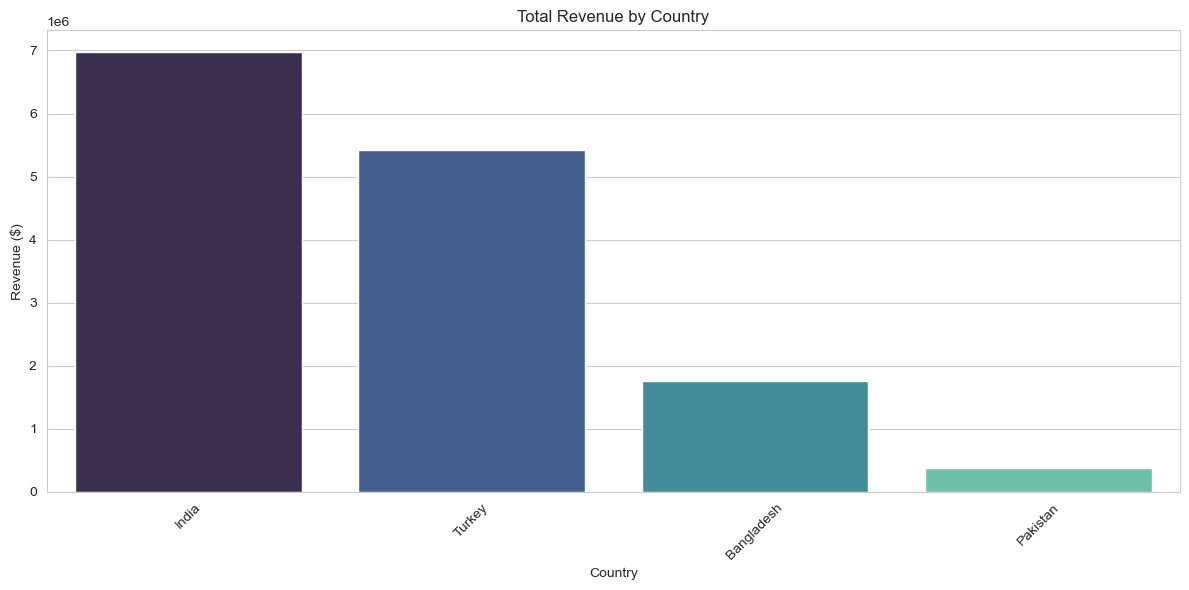

In [10]:
# Sales by country
country_sales = sales_df.groupby('Country').agg({
    'Units_Sold': 'sum',
    'Total_Revenue': 'sum'
}).sort_values('Total_Revenue', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_sales.index, y=country_sales['Total_Revenue'], palette='mako')
plt.title('Total Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



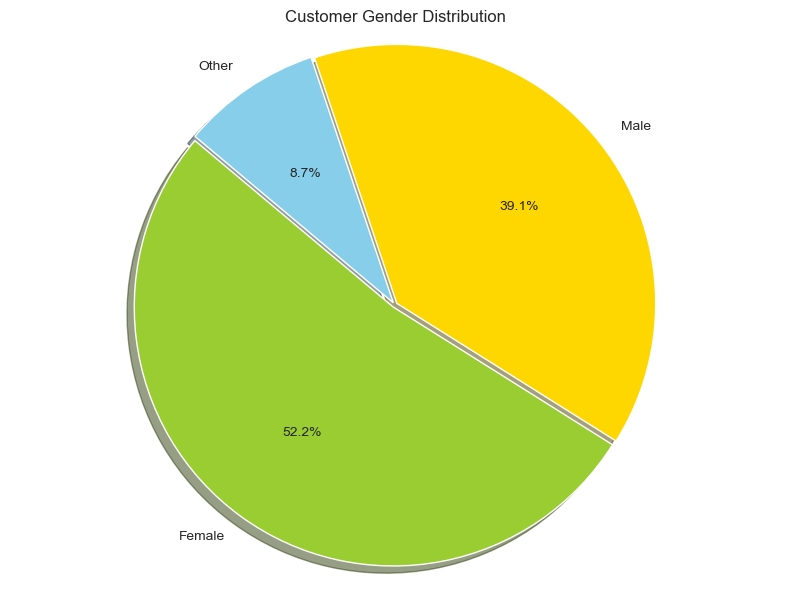

In [19]:

# Gender distribution
gender_dist = sales_df['Customer_Gender'].value_counts()

plt.figure(figsize=(8, 6))
explode = (0.01, 0.01, 0.01)
plt.pie(gender_dist, explode=explode, labels=gender_dist.index, autopct='%1.1f%%', colors=['yellowgreen', 'gold', 'skyblue'], shadow=True, 
        startangle=140)
plt.title('Customer Gender Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

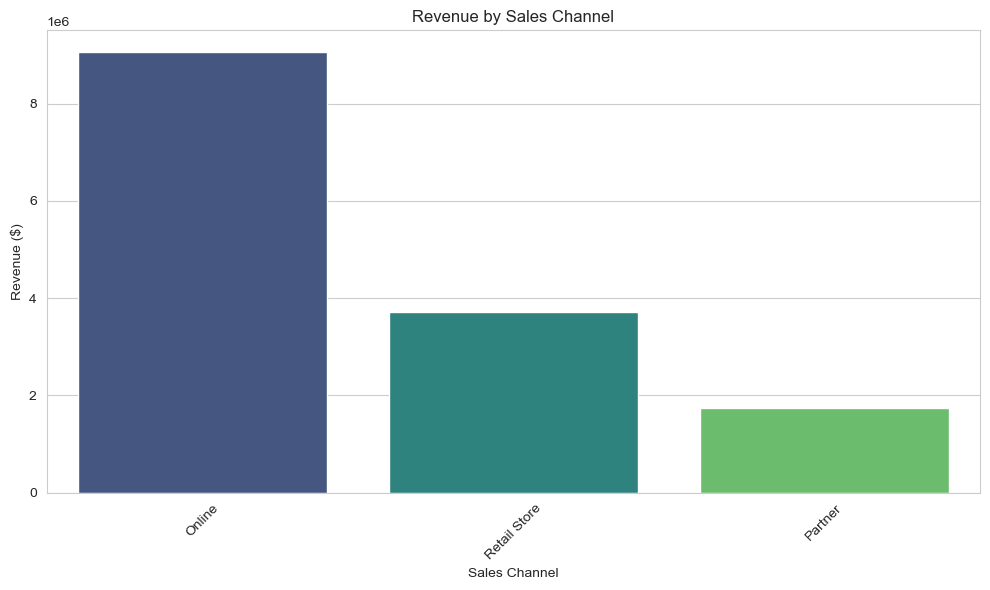

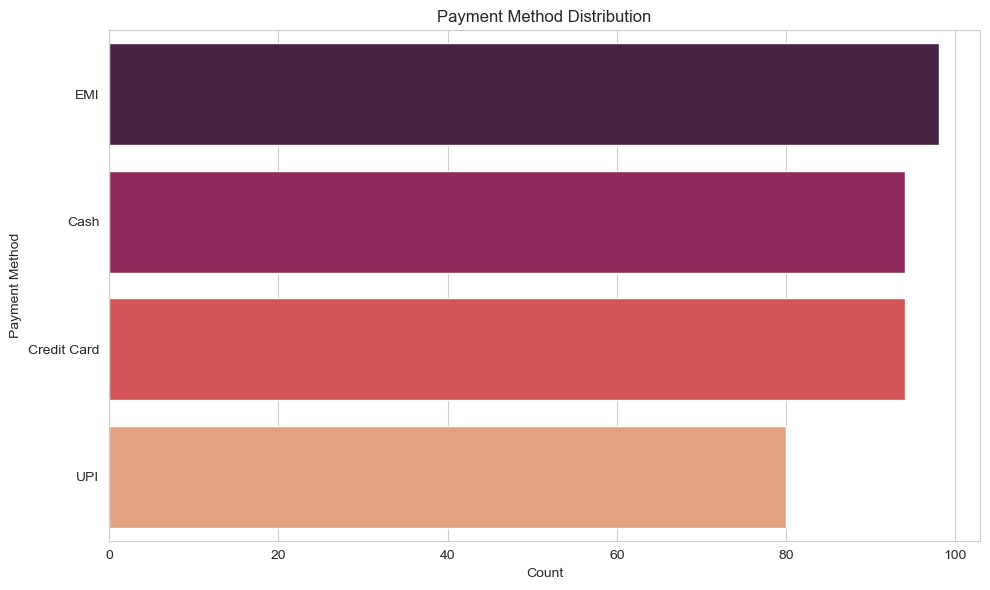

In [20]:
# Sales channel performance
channel_performance = sales_df.groupby('Sales_Channel').agg({
    'Units_Sold': 'sum',
    'Total_Revenue': 'sum'
}).sort_values('Total_Revenue', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=channel_performance.index, y=channel_performance['Total_Revenue'], palette='viridis')
plt.title('Revenue by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Payment method distribution
payment_methods = sales_df['Payment_Type'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=payment_methods.values, y=payment_methods.index, palette='rocket')
plt.title('Payment Method Distribution')
plt.xlabel('Count')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()

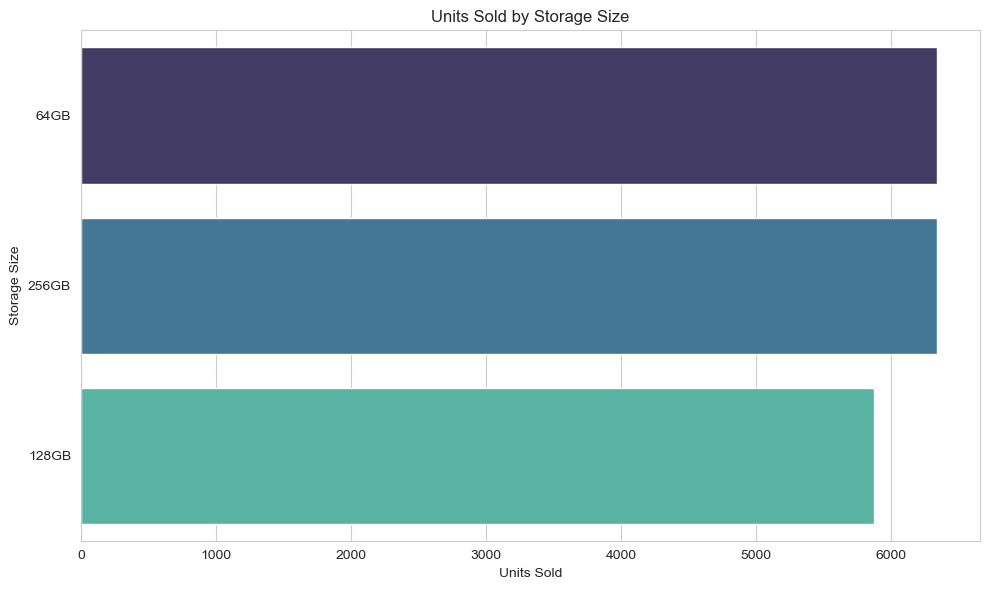

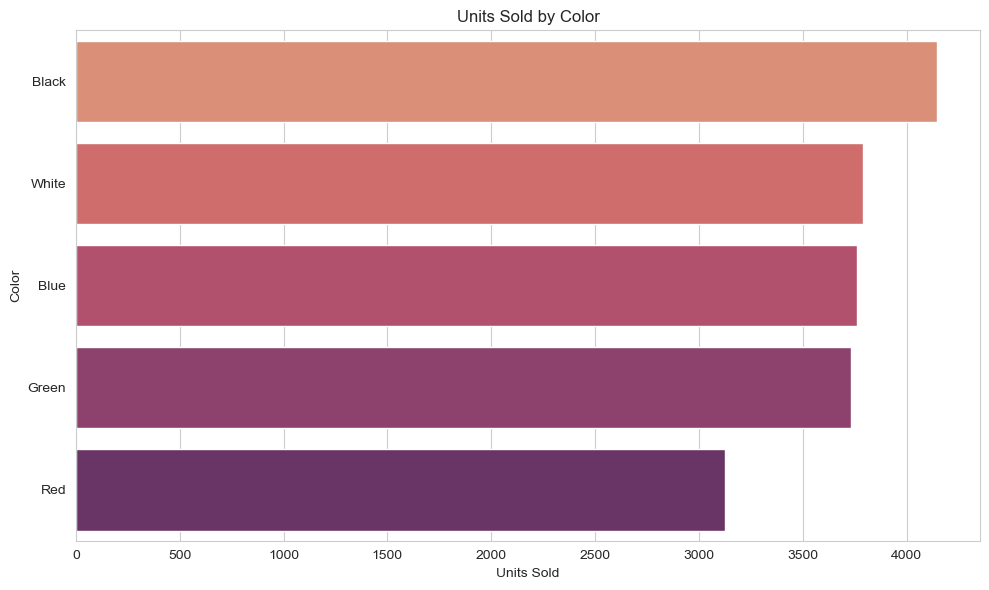

In [21]:
# Storage size preference
storage_pref = sales_df.groupby('Storage_Size')['Units_Sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=storage_pref.values, y=storage_pref.index, palette='mako')
plt.title('Units Sold by Storage Size')
plt.xlabel('Units Sold')
plt.ylabel('Storage Size')
plt.tight_layout()
plt.show()

# Color preference
color_pref = sales_df.groupby('Color')['Units_Sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=color_pref.values, y=color_pref.index, palette='flare')
plt.title('Units Sold by Color')
plt.xlabel('Units Sold')
plt.ylabel('Color')
plt.tight_layout()
plt.show()

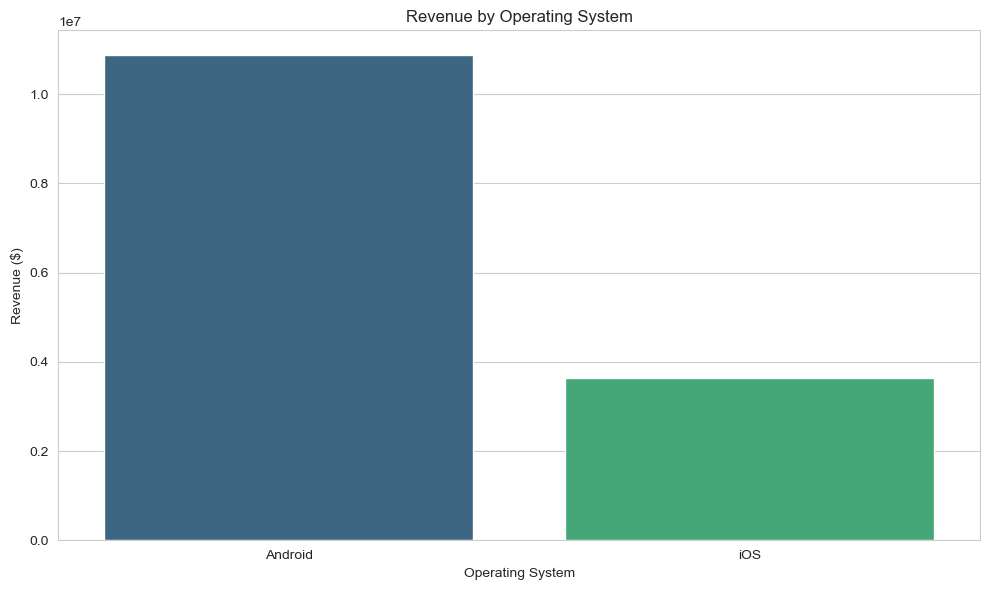

In [22]:
# OS performance
os_performance = sales_df.groupby('Operating_System').agg({
    'Units_Sold': 'sum',
    'Total_Revenue': 'sum'
}).sort_values('Total_Revenue', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=os_performance.index, y=os_performance['Total_Revenue'], palette='viridis')
plt.title('Revenue by Operating System')
plt.xlabel('Operating System')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

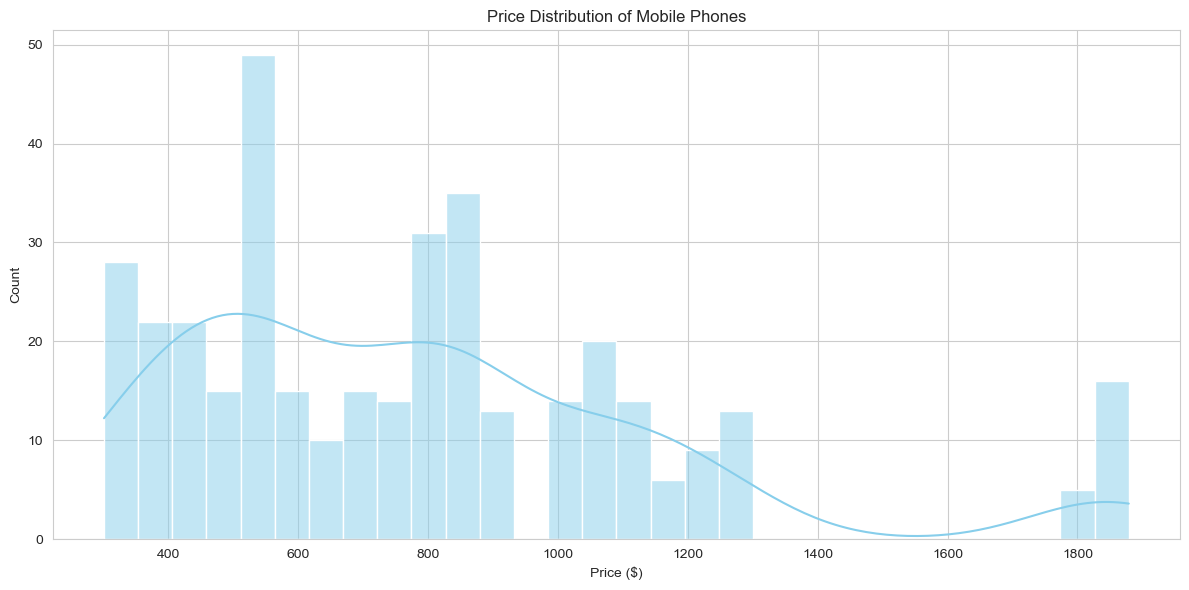

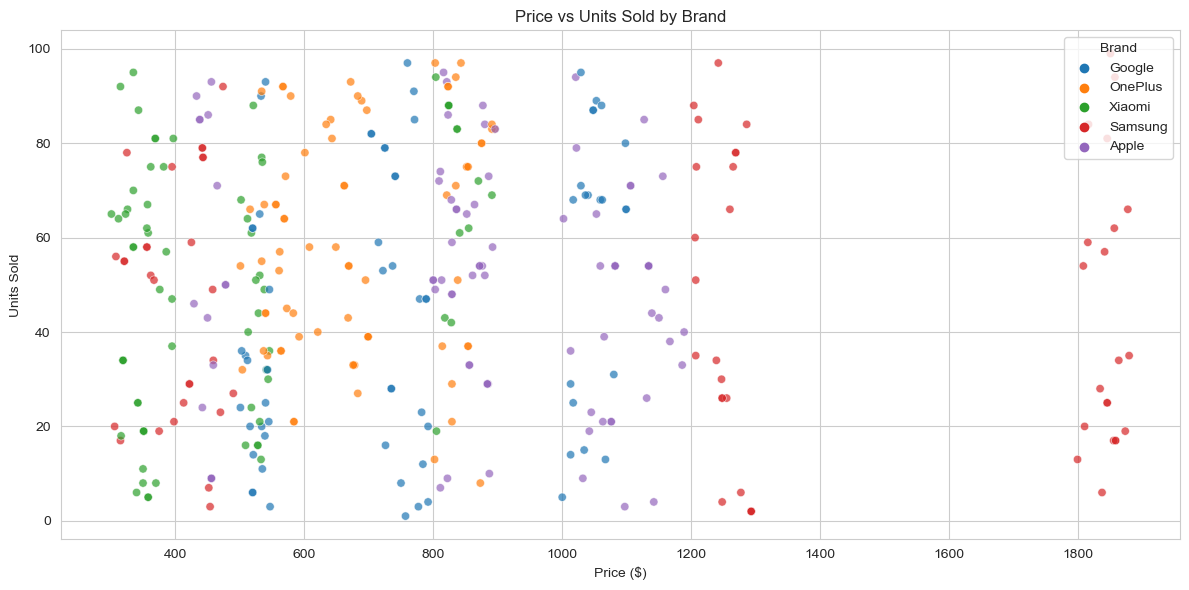

In [23]:
# Price distribution
plt.figure(figsize=(12, 6))
sns.histplot(sales_df['Price'], bins=30, kde=True, color='skyblue')
plt.title('Price Distribution of Mobile Phones')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Price vs Units Sold
plt.figure(figsize=(12, 6))
sns.scatterplot(data=sales_df, x='Price', y='Units_Sold', hue='Brand', alpha=0.7)
plt.title('Price vs Units Sold by Brand')
plt.xlabel('Price ($)')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

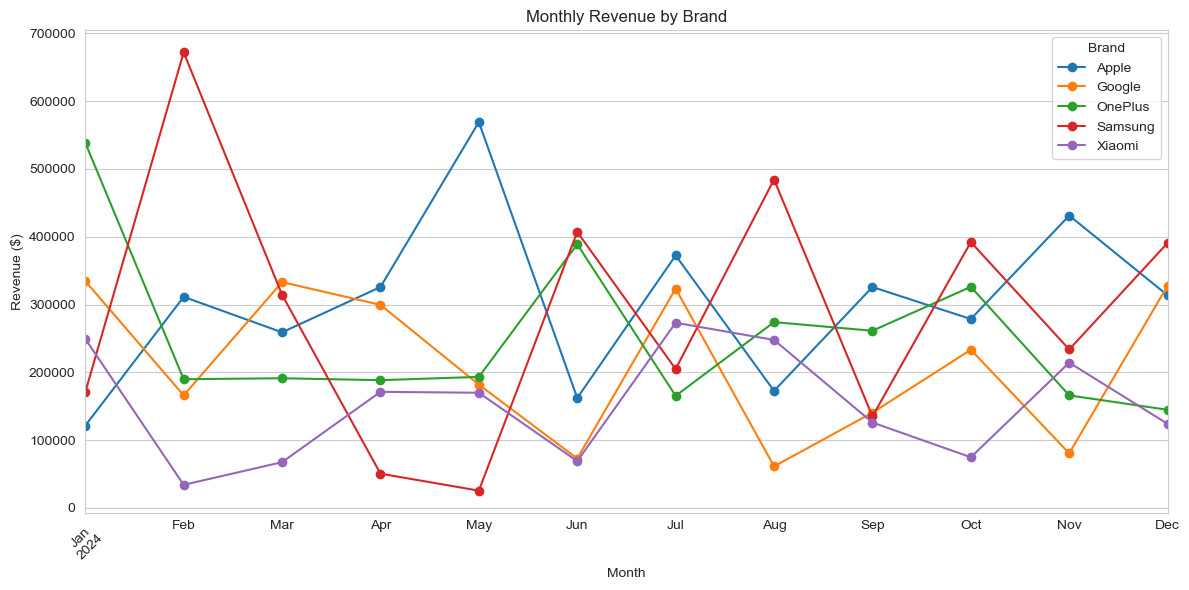

In [25]:
# Monthly performance by brand
monthly_brand = sales_df.groupby([pd.Grouper(key='End of Month', freq='M'), 'Brand'])['Total_Revenue'].sum().unstack()

plt.figure(figsize=(14, 8))
monthly_brand.plot(kind='line', marker='o')
plt.title('Monthly Revenue by Brand')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend(title='Brand')
plt.grid(True)
plt.tight_layout()
plt.show()

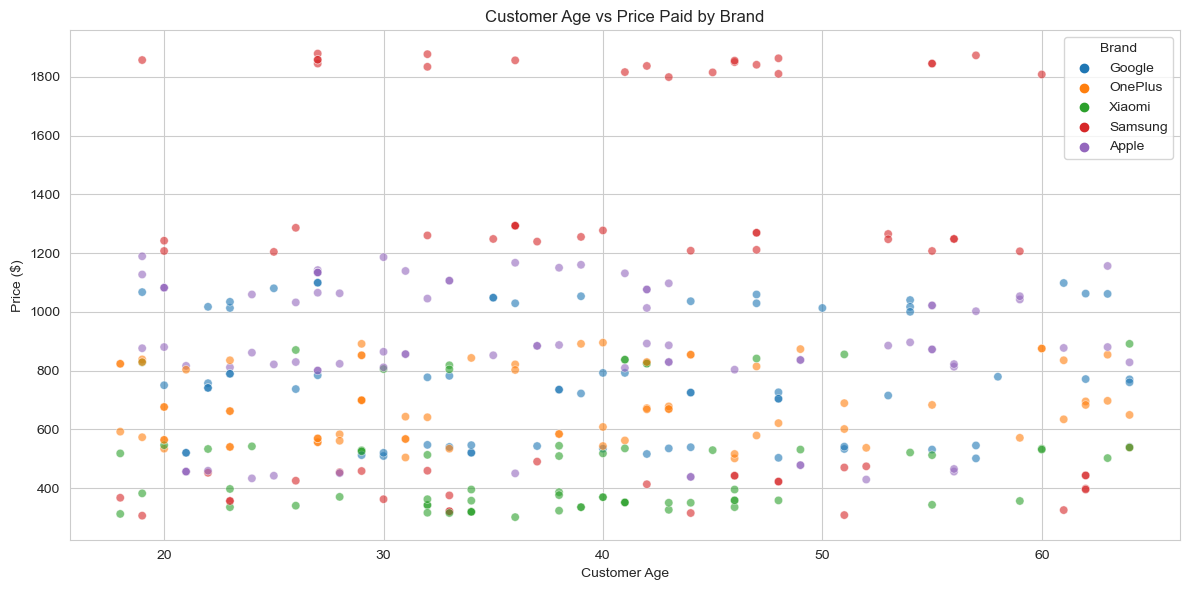

In [24]:
# Age vs Price
plt.figure(figsize=(12, 6))
sns.scatterplot(data=sales_df, x='Customer_Age', y='Price', hue='Brand', alpha=0.6)
plt.title('Customer Age vs Price Paid by Brand')
plt.xlabel('Customer Age')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()